# TenCirChem: H4 top-important doubles

This notebook runs **linear H₄** (STO-3G) so you can play with how many UCCSD
**double excitations** are enough for chemical accuracy.

Qubit count:
- Full STO-3G H₄: **4 spatial orbitals → 8 qubits** (4 electrons). No frozen core.
- After the usual 2-qubit Z₂ taper (α/β spin-block parity, as in `state_transfer/taper_lib.py`):
  **8 → 6 tapered qubits**.

Tasks (same pattern as `HF.ipynb`):

1. At each bond length, rank doubles by `|MP2 initial θ|` at that geometry
   and keep top-`k` (`top_k` below) — not one fixed ansatz for the whole scan.
2. Scan the H–H spacing along the linear chain and plot the total energy
   curve (and error vs FCI) vs bond length.
3. Sweep `k = 1 .. n_doubles` at one geometry to see how many doubles are enough.



In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy.optimize import minimize_scalar

from tencirchem import UCCSD, M
from tencirchem.static.ci_utils import get_ci_strings, get_init_civector

plt.style.use("seaborn-v0_8-whitegrid")
CHEM_ACC_MHA = 1.6  # ~1 kcal/mol

from tencirchem.molecule import h_chain



/Users/zacharyhe/cross_chips_sim/.venv_h4_tencirchem/lib/python3.9/site-packages/urllib3/__init__.py:35: NotOpenSSLWarning: urllib3 v2 only supports OpenSSL 1.1.1+, currently the 'ssl' module is compiled with 'LibreSSL 2.8.3'. See: https://github.com/urllib3/urllib3/issues/3020
  warnings.warn(


In [2]:
# Linear H4 chain: H-H spacing d (angstrom). Atoms at 0, d, 2d, 3d.
# NOTE: tencirchem.molecule.h4 is a fixed Mole at d=0.8 A (not a factory).
# Calling h4(d) silently ignores d via Mole.set(); use h_chain instead.
def make_h4(d):
    return h_chain(n_h=4, bond_distance=float(d))


# Full valence: 4e in 4 spatial orbitals -> 8 qubits. Taper later -> 6q.
active_space = (4, 4)
N_SPATIAL_ORBITALS = active_space[1]
N_QUBITS = 2 * N_SPATIAL_ORBITALS          # 8 (pre-taper)
N_QUBITS_TAPERED = N_QUBITS - 2            # 6
N_ACTIVE_ELECTRONS = active_space[0]
ETA = N_ACTIVE_ELECTRONS // 2

# H-H spacing scan (A)
d_grid = np.round(np.arange(0.6, 2.0, 0.2), 2)

def _paper_hf_and_excited_bitstrings(n_qubits, n_elec):
    """Paper qubit layout: alpha sector (low MO index first), then beta sector."""
    eta = n_elec // 2
    half = n_qubits // 2

    hf = []
    for _sector in range(2):
        hf.extend(["1" if local < eta else "0" for local in range(half)])

    exc = hf.copy()
    exc[eta - 1] = "0"
    exc[eta + half - 1] = "0"
    exc[eta] = "1"
    exc[eta + half] = "1"
    return "".join(hf), "".join(exc)


def _paper_to_tencirchem_bitstring(paper_bits, n_qubits, n_elec):
    """Map paper spin-orbital bit order to TenCirChem's internal qubit order."""
    eta = n_elec // 2
    half = n_qubits // 2
    tc_bits = ["0"] * n_qubits

    for sector_start in (0, half):
        for local in range(half):
            if paper_bits[sector_start + local] != "1":
                continue
            if local < eta:
                tc_local = local + (half - eta)
            else:
                tc_local = local - eta
            tc_bits[sector_start + tc_local] = "1"

    return "".join(tc_bits)


def build_multireference_init_civector(ucc, beta):
    """Paper Eq. (6): (|HF> - beta|exc>) / sqrt(1 + beta^2) in TenCirChem CI basis."""
    if beta == 0.0:
        return None

    n_qubits = ucc.n_qubits
    n_elec = ucc.n_elec
    ci_strings = get_ci_strings(n_qubits, n_elec, ucc.hcb)
    hf_ci = get_init_civector(len(ci_strings))

    _, paper_exc = _paper_hf_and_excited_bitstrings(n_qubits, n_elec)
    exc_bits = _paper_to_tencirchem_bitstring(paper_exc, n_qubits, n_elec)
    exc_addr = int(exc_bits, 2)
    exc_idx = int(np.where(ci_strings == exc_addr)[0][0])

    norm = 1.0 / np.sqrt(1.0 + beta**2)
    ref_ci = np.zeros(len(ci_strings), dtype=float)
    ref_ci[0] = norm
    ref_ci[exc_idx] = -beta * norm
    return ref_ci


def optimize_multireference_beta(ucc, beta_bounds=(-5.0, 5.0)):
    """min_beta <Psi_ref(beta)|H|Psi_ref(beta)> at zero UCC params."""

    def ref_energy(beta):
        saved = ucc.init_state
        ucc.init_state = build_multireference_init_civector(ucc, beta)
        e = ucc.energy(np.zeros(ucc.n_params))
        ucc.init_state = saved
        return e

    res = minimize_scalar(ref_energy, bounds=beta_bounds, method="bounded")
    return float(res.x)


def configure_ucc_initial_state(
    ucc,
    use_multireference=False,
    beta=None,
    optimize_beta=True,
    beta_bounds=(-5.0, 5.0),
):
    """Configure UCC initial state before kernel(). Default = RHF HF."""
    if not use_multireference:
        ucc.init_state = None
        return 0.0

    if beta is None and optimize_beta:
        beta = optimize_multireference_beta(ucc, beta_bounds=beta_bounds)
    elif beta is None:
        beta = 0.0

    ucc.init_state = build_multireference_init_civector(ucc, beta)
    return float(beta)

print(
    f"H4 active space: {N_ACTIVE_ELECTRONS} electrons, {N_SPATIAL_ORBITALS} spatial orbitals "
    f"-> {N_QUBITS} qubits (eta={ETA}); after Z2 taper -> {N_QUBITS_TAPERED} qubits"
)
print(f"Scanning H-H spacings (A): {d_grid.tolist()}")



H4 active space: 4 electrons, 4 spatial orbitals -> 8 qubits (eta=2); after Z2 taper -> 6 qubits
Scanning H-H spacings (A): [0.6, 0.8, 1.0, 1.2, 1.4, 1.6, 1.8]


In [3]:
# Demo: HF vs paper multi-reference initial state (default is HF)
demo_d = 1.0
demo_mol = make_h4(demo_d)
demo_ucc = UCCSD(
    demo_mol,
    active_space=active_space,
    init_method="mp2",
    pick_ex2=False,
    sort_ex2=False,
    run_fci=True,
)

configure_ucc_initial_state(demo_ucc, use_multireference=False)
e_hf = demo_ucc.energy(np.zeros(demo_ucc.n_params))

beta_demo = configure_ucc_initial_state(demo_ucc, use_multireference=True, optimize_beta=True)
e_mr = demo_ucc.energy(np.zeros(demo_ucc.n_params))

paper_hf, paper_exc = _paper_hf_and_excited_bitstrings(demo_ucc.n_qubits, demo_ucc.n_elec)
init_demo_df = pd.DataFrame(
    [
        {
            "d_angstrom": demo_d,
            "beta_optimized": beta_demo,
            "E_ref_HF_Ha": e_hf,
            "E_ref_multireference_Ha": e_mr,
            "E_FCI_Ha": demo_ucc.e_fci,
            "HF_minus_FCI_mHa": (e_hf - demo_ucc.e_fci) * 1000,
            "multiref_minus_FCI_mHa": (e_mr - demo_ucc.e_fci) * 1000,
            "paper_HF_bitstring": paper_hf,
            "paper_excited_bitstring": paper_exc,
            "tc_excited_bitstring": _paper_to_tencirchem_bitstring(
                paper_exc, demo_ucc.n_qubits, demo_ucc.n_elec
            ),
        }
    ]
)

print(f"Initial-state demo at d = {demo_d:.2f} A")
display(init_demo_df)
configure_ucc_initial_state(demo_ucc, use_multireference=False)



Initial-state demo at d = 1.00 A


,d_angstrom,beta_optimized,E_ref_HF_Ha,E_ref_multireference_Ha,E_FCI_Ha,HF_minus_FCI_mHa,multiref_minus_FCI_mHa,paper_HF_bitstring,paper_excited_bitstring,tc_excited_bitstring
0,1.0,0.044873,-2.098546,-2.102902,-2.166387,67.841512,63.485723,11001100,10101010,10101010


0.0

In [4]:
def build_reduced_topk_doubles_ucc(mol, active_space, k, fixed_pids=None):
    """Build a UCCSD instance that keeps top-k MP2-important double parameters only.

    If ``fixed_pids`` is given, those exact double parameter ids are kept instead of
    re-ranking by MP2 amplitude at this geometry. Kept amplitudes are initialized
    from the MP2 guess at *this* molecule/geometry.
    """
    probe = UCCSD(
        mol,
        active_space=active_space,
        init_method="mp2",
        pick_ex2=False,
        sort_ex2=False,
        run_fci=False,
    )

    all_ops = probe.ex_ops
    all_param_ids = probe.param_ids
    all_init_guess = probe.init_guess

    pid_to_ops = {}
    for op, pid in zip(all_ops, all_param_ids):
        pid_to_ops.setdefault(pid, []).append(op)

    double_pids = [pid for pid, ops in pid_to_ops.items() if all(len(op) == 4 for op in ops)]
    if len(double_pids) == 0:
        raise ValueError("No double-excitation parameters found.")

    pid_to_guess = {pid: all_init_guess[pid] for pid in double_pids}
    if fixed_pids is None:
        sorted_pids = sorted(double_pids, key=lambda pid: abs(pid_to_guess[pid]), reverse=True)
        selected_pids = sorted_pids[:k]
    else:
        selected_pids = list(fixed_pids)

    selected_pids_set = set(selected_pids)
    selected_ex_ops = []
    selected_param_ids = []
    selected_pid_to_ops = {pid: [] for pid in selected_pids}
    for op, pid in zip(all_ops, all_param_ids):
        if pid in selected_pids_set:
            selected_ex_ops.append(op)
            selected_param_ids.append(pid)
            selected_pid_to_ops[pid].append(op)

    pid_remap = {old_pid: new_pid for new_pid, old_pid in enumerate(selected_pids)}
    selected_param_ids = [pid_remap[pid] for pid in selected_param_ids]
    # Use MP2 amplitudes from this geometry (not zeros / not a fixed reference d).
    selected_init_guess = [pid_to_guess[pid] for pid in selected_pids]

    reduced = UCCSD(
        mol,
        active_space=active_space,
        init_method="zeros",
        pick_ex2=False,
        sort_ex2=False,
        run_fci=False,
    )
    reduced.ex_ops = selected_ex_ops
    reduced.param_ids = selected_param_ids
    reduced.init_guess = selected_init_guess

    def op_to_string(op):
        p, q, r, s = op
        return f"a{p}dag a{q}dag a{r} a{s}"

    selected_rows = []
    for rank, pid in enumerate(selected_pids, start=1):
        linked_ops = selected_pid_to_ops[pid]
        selected_rows.append(
            {
                "rank": rank,
                "param_id_index": pid,
                "factor_type": "double",
                "mp2_init_theta": pid_to_guess[pid],
                "abs_mp2_init_theta": abs(pid_to_guess[pid]),
                "n_ex_ops_linked": len(linked_ops),
                "op_terms": " | ".join(op_to_string(op) for op in linked_ops),
            }
        )

    selected_meta_df = pd.DataFrame(selected_rows)
    return reduced, selected_pids, selected_ex_ops, selected_meta_df


# <-- play with this: number of MP2-ranked doubles kept in the bond scan
top_k = 8
scan_rows = []

# At each bond length: re-rank doubles by |MP2 θ| and seed with that geometry's MP2.
report_d = 1.0
selected_meta_df = None

for d in d_grid:
    mol = make_h4(d)

    # Full space (== active space for H4).
    ucc_as = UCCSD(
        mol,
        active_space=active_space,
        init_method="mp2",
        pick_ex2=True,
        sort_ex2=True,
        run_fci=True,
    )
    e_as = ucc_as.kernel()
    e_fci_as = ucc_as.e_fci
    e_hf = ucc_as.e_hf

    reduced_ucc_d, selected_pids_d, selected_ex_ops_d, meta_d = build_reduced_topk_doubles_ucc(
        mol, active_space, top_k
    )
    e_topk_doubles = reduced_ucc_d.kernel()
    if abs(d - report_d) < 1e-12:
        selected_meta_df = meta_d

    scan_rows.append(
        {
            "d_angstrom": d,
            "E_HF_Ha": e_hf,
            "E_active_space_Ha": e_as,
            "E_topk_doubles_Ha": e_topk_doubles,
            "topk_minus_active_mHa": (e_topk_doubles - e_as) * 1000,
            "topk_minus_fci_active_mHa": (e_topk_doubles - e_fci_as) * 1000,
            "n_ex_ops_kept": len(selected_ex_ops_d),
            "selected_param_ids": str(selected_pids_d),
            "mp2_init_thetas": str([round(float(x), 6) for x in meta_d["mp2_init_theta"].tolist()]),
        }
    )

scan_df = pd.DataFrame(scan_rows).sort_values("d_angstrom").reset_index(drop=True)

summary_df = scan_df[
    [
        "d_angstrom",
        "E_HF_Ha",
        "E_active_space_Ha",
        "E_topk_doubles_Ha",
        "topk_minus_active_mHa",
        "topk_minus_fci_active_mHa",
        "selected_param_ids",
        "mp2_init_thetas",
    ]
].copy()

print(
    f"Top-{top_k} doubles are re-ranked by |MP2 initial theta| at each bond length "
    f"and seeded with that geometry's MP2 amplitudes."
)
print(f"Detailed top-{top_k} doubles below are for d = {report_d:.2f} A")
print(f"Pre-taper qubits = {N_QUBITS}; after Z2 taper = {N_QUBITS_TAPERED}")
display(selected_meta_df)
display(summary_df)



Optimization failed. See `.opt_res` for details.


Top-8 doubles are re-ranked by |MP2 initial theta| at each bond length and seeded with that geometry's MP2 amplitudes.
Detailed top-8 doubles below are for d = 1.00 A
Pre-taper qubits = 8; after Z2 taper = 6


,rank,param_id_index,factor_type,mp2_init_theta,abs_mp2_init_theta,n_ex_ops_linked,op_terms
0,1,12,double,-1.010703e-01,1.010703e-01,1,a2dag a6dag a5 a1
1,2,5,double,-5.860813e-02,5.860813e-02,1,a2dag a6dag a4 a0
2,3,9,double,-4.543451e-02,4.543451e-02,2,a2dag a7dag a5 a0 | a6dag a3dag a1 a4
3,4,14,double,-4.191515e-02,4.191515e-02,1,a3dag a7dag a5 a1
4,5,7,double,-3.259341e-02,3.259341e-02,1,a3dag a7dag a4 a0
5,6,10,double,-2.442558e-02,2.442558e-02,2,a3dag a6dag a5 a0 | a7dag a2dag a1 a4
6,7,4,double,-2.100893e-02,2.100893e-02,2,a6dag a7dag a5 a4 | a2dag a3dag a1 a0
7,8,6,double,-5.948750e-17,5.948750e-17,2,a2dag a7dag a4 a0 | a6dag a3dag a0 a4


,d_angstrom,E_HF_Ha,E_active_space_Ha,E_topk_doubles_Ha,topk_minus_active_mHa,topk_minus_fci_active_mHa,selected_param_ids,mp2_init_thetas
0,0.6,-1.929564,-1.960188,-1.960113,0.074464,0.080313,"[12, 5, 9, 14, 7, 4, 10, 13]","[-0.062808, -0.033507, -0.021659, -0.019206, -..."
1,0.8,-2.121387,-2.167546,-2.167444,0.101832,0.116216,"[12, 5, 9, 14, 7, 4, 10, 13]","[-0.081208, -0.045444, -0.032406, -0.029495, -..."
2,1.0,-2.098546,-2.166308,-2.166211,0.097163,0.176374,"[12, 5, 9, 14, 7, 10, 4, 6]","[-0.10107, -0.058608, -0.045435, -0.041915, -0..."
3,1.2,-2.003867,-2.102295,-2.102215,0.080131,0.393792,"[12, 5, 9, 14, 7, 10, 4, 8]","[-0.123533, -0.073704, -0.061604, -0.057781, -..."
4,1.4,-1.887790,-2.028175,-2.028096,0.078772,0.974714,"[12, 5, 9, 14, 7, 10, 4, 13]","[-0.149165, -0.091904, -0.081561, -0.077807, -..."
5,1.6,-1.772203,-1.965628,-1.965520,0.107361,2.039826,"[12, 5, 9, 14, 7, 10, 4, 11]","[-0.178034, -0.114023, -0.105681, -0.102303, -..."
6,1.8,-1.666867,-1.921178,-1.921035,0.143550,3.396001,"[12, 5, 9, 14, 10, 7, 4, 11]","[-0.2098, -0.140547, -0.13425, -0.131515, -0.1..."


Optimization failed. See `.opt_res` for details.


Convergence demo at d = 1.00 A  (no=2, nv=2, total doubles=11)
HF  = -2.09854594 Ha
FCI = -2.16638745 Ha   full UCCSD = -2.16630824 Ha
First k with error <= 1.6 mHa: k = 7


,n_doubles_kept,n_ex_ops,E_reduced_Ha,error_vs_FCI_mHa
0,1,1,-2.122500,43.887582
1,2,2,-2.127603,38.784425
2,3,4,-2.149429,16.958936
3,4,5,-2.153106,13.281704
4,5,6,-2.158650,7.737914
5,6,8,-2.163919,2.468724
6,7,10,-2.166211,0.176374
7,8,12,-2.166211,0.176374
8,9,14,-2.166211,0.176374
9,10,16,-2.166211,0.176374


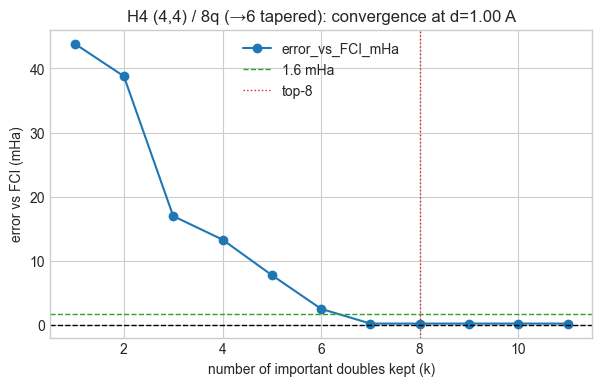

In [5]:
# Convergence vs number of doubles kept — the main "how many is enough?" cell.
# Change conv_d or re-run after editing; sweeps k = 1 .. n_doubles_total.

conv_d = 1.0
conv_mol = make_h4(conv_d)

conv_ref = UCCSD(
    conv_mol,
    active_space=active_space,
    init_method="mp2",
    pick_ex2=True,
    sort_ex2=True,
    run_fci=True,
)
e_full_conv = conv_ref.kernel()
e_fci_conv = conv_ref.e_fci

probe_conv = UCCSD(
    conv_mol,
    active_space=active_space,
    init_method="mp2",
    pick_ex2=False,
    sort_ex2=False,
    run_fci=False,
)
_pid_ops = {}
for op, pid in zip(probe_conv.ex_ops, probe_conv.param_ids):
    _pid_ops.setdefault(pid, []).append(op)
n_doubles_total = sum(1 for ops in _pid_ops.values() if all(len(o) == 4 for o in ops))

conv_rows = []
for k in range(1, n_doubles_total + 1):
    red_k, _, ex_ops_k, _ = build_reduced_topk_doubles_ucc(conv_mol, active_space, k)
    e_k = red_k.kernel()
    conv_rows.append(
        {
            "n_doubles_kept": k,
            "n_ex_ops": len(ex_ops_k),
            "E_reduced_Ha": e_k,
            "error_vs_FCI_mHa": (e_k - e_fci_conv) * 1000,
        }
    )

conv_df = pd.DataFrame(conv_rows)
enough = conv_df.loc[conv_df["error_vs_FCI_mHa"] <= CHEM_ACC_MHA, "n_doubles_kept"]
k_chem = int(enough.iloc[0]) if len(enough) else None

print(
    f"Convergence demo at d = {conv_d:.2f} A  "
    f"(no={N_ACTIVE_ELECTRONS // 2}, nv={N_SPATIAL_ORBITALS - N_ACTIVE_ELECTRONS // 2}, "
    f"total doubles={n_doubles_total})"
)
print(f"HF  = {conv_ref.e_hf:.8f} Ha")
print(f"FCI = {e_fci_conv:.8f} Ha   full UCCSD = {e_full_conv:.8f} Ha")
if k_chem is not None:
    print(f"First k with error <= {CHEM_ACC_MHA} mHa: k = {k_chem}")
else:
    print(f"No k reached chemical accuracy ({CHEM_ACC_MHA} mHa) in this sweep.")
display(conv_df)

ax = conv_df.plot(
    x="n_doubles_kept",
    y="error_vs_FCI_mHa",
    marker="o",
    legend=False,
    figsize=(7, 4),
)
ax.axhline(0.0, color="black", linestyle="--", linewidth=1.0)
ax.axhline(CHEM_ACC_MHA, color="tab:green", linestyle="--", linewidth=1.0, label=f"{CHEM_ACC_MHA} mHa")
ax.axvline(top_k, color="tab:red", linestyle=":", linewidth=1.0, label=f"top-{top_k}")
ax.set_xlabel("number of important doubles kept (k)")
ax.set_ylabel("error vs FCI (mHa)")
ax.set_title(f"H4 (4,4) / 8q (→6 tapered): convergence at d={conv_d:.2f} A")
ax.legend()
plt.show()



,d_angstrom,E_HF_Ha,E_active_space_Ha,E_topk_doubles_Ha,topk_minus_active_mHa,topk_minus_fci_active_mHa,n_ex_ops_kept,selected_param_ids,mp2_init_thetas
0,0.6,-1.929564,-1.960188,-1.960113,0.074464,0.080313,12,"[12, 5, 9, 14, 7, 4, 10, 13]","[-0.062808, -0.033507, -0.021659, -0.019206, -..."
1,0.8,-2.121387,-2.167546,-2.167444,0.101832,0.116216,12,"[12, 5, 9, 14, 7, 4, 10, 13]","[-0.081208, -0.045444, -0.032406, -0.029495, -..."
2,1.0,-2.098546,-2.166308,-2.166211,0.097163,0.176374,12,"[12, 5, 9, 14, 7, 10, 4, 6]","[-0.10107, -0.058608, -0.045435, -0.041915, -0..."
3,1.2,-2.003867,-2.102295,-2.102215,0.080131,0.393792,12,"[12, 5, 9, 14, 7, 10, 4, 8]","[-0.123533, -0.073704, -0.061604, -0.057781, -..."
4,1.4,-1.887790,-2.028175,-2.028096,0.078772,0.974714,12,"[12, 5, 9, 14, 7, 10, 4, 13]","[-0.149165, -0.091904, -0.081561, -0.077807, -..."
5,1.6,-1.772203,-1.965628,-1.965520,0.107361,2.039826,12,"[12, 5, 9, 14, 7, 10, 4, 11]","[-0.178034, -0.114023, -0.105681, -0.102303, -..."
6,1.8,-1.666867,-1.921178,-1.921035,0.143550,3.396001,12,"[12, 5, 9, 14, 10, 7, 4, 11]","[-0.2098, -0.140547, -0.13425, -0.131515, -0.1..."


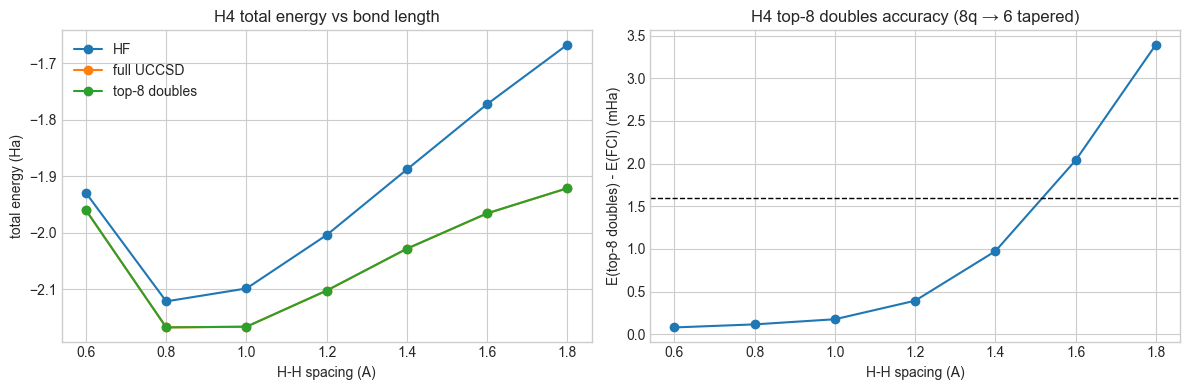

In [6]:
display(scan_df)

fig, axes = plt.subplots(1, 2, figsize=(12, 4))

# Total energy curve vs H-H spacing
scan_df.plot(
    x="d_angstrom",
    y=["E_HF_Ha", "E_active_space_Ha", "E_topk_doubles_Ha"],
    marker="o",
    ax=axes[0],
)
axes[0].set_xlabel("H-H spacing (A)")
axes[0].set_ylabel("total energy (Ha)")
axes[0].set_title("H4 total energy vs bond length")
axes[0].legend(["HF", "full UCCSD", f"top-{top_k} doubles"])

# Error vs FCI
scan_df.plot(
    x="d_angstrom",
    y="topk_minus_fci_active_mHa",
    marker="o",
    legend=False,
    ax=axes[1],
)
axes[1].axhline(CHEM_ACC_MHA, color="black", linestyle="--", linewidth=1.0)
axes[1].set_xlabel("H-H spacing (A)")
axes[1].set_ylabel(f"E(top-{top_k} doubles) - E(FCI) (mHa)")
axes[1].set_title(f"H4 top-{top_k} doubles accuracy (8q → 6 tapered)")

plt.tight_layout()
plt.show()



Fixed ansatz uses the SAME doubles [12, 5, 9, 14, 7, 4, 10, 13] at every bond length (MP2 amplitudes still taken from each geometry).
Operator details below are for d = 1.00 A


,rank,param_id_index,factor_type,mp2_init_theta,abs_mp2_init_theta,n_ex_ops_linked,op_terms
0,1,12,double,-1.010703e-01,1.010703e-01,1,a2dag a6dag a5 a1
1,2,5,double,-5.860813e-02,5.860813e-02,1,a2dag a6dag a4 a0
2,3,9,double,-4.543451e-02,4.543451e-02,2,a2dag a7dag a5 a0 | a6dag a3dag a1 a4
3,4,14,double,-4.191515e-02,4.191515e-02,1,a3dag a7dag a5 a1
4,5,7,double,-3.259341e-02,3.259341e-02,1,a3dag a7dag a4 a0
5,6,4,double,-2.100893e-02,2.100893e-02,2,a6dag a7dag a5 a4 | a2dag a3dag a1 a0
6,7,10,double,-2.442558e-02,2.442558e-02,2,a3dag a6dag a5 a0 | a7dag a2dag a1 a4
7,8,13,double,2.890141e-17,2.890141e-17,2,a2dag a7dag a5 a1 | a6dag a3dag a1 a5


,d_angstrom,E_HF_Ha,E_active_space_Ha,E_fixed_doubles_Ha,fixed_minus_active_mHa,fixed_minus_fci_active_mHa,n_ex_ops_kept,selected_param_ids,mp2_init_thetas
0,0.6,-1.929564,-1.960188,-1.960113,0.074464,0.080313,12,"[12, 5, 9, 14, 7, 4, 10, 13]","[-0.062808, -0.033507, -0.021659, -0.019206, -..."
1,0.8,-2.121387,-2.167546,-2.167444,0.101832,0.116216,12,"[12, 5, 9, 14, 7, 4, 10, 13]","[-0.081208, -0.045444, -0.032406, -0.029495, -..."
2,1.0,-2.098546,-2.166308,-2.166211,0.097163,0.176374,12,"[12, 5, 9, 14, 7, 4, 10, 13]","[-0.10107, -0.058608, -0.045435, -0.041915, -0..."
3,1.2,-2.003867,-2.102295,-2.102215,0.080131,0.393792,12,"[12, 5, 9, 14, 7, 4, 10, 13]","[-0.123533, -0.073704, -0.061604, -0.057781, -..."
4,1.4,-1.887790,-2.028175,-2.028096,0.078772,0.974714,12,"[12, 5, 9, 14, 7, 4, 10, 13]","[-0.149165, -0.091904, -0.081561, -0.077807, -..."
5,1.6,-1.772203,-1.965628,-1.965520,0.107361,2.039826,12,"[12, 5, 9, 14, 7, 4, 10, 13]","[-0.178034, -0.114023, -0.105681, -0.102303, -..."
6,1.8,-1.666867,-1.921178,-1.921035,0.143550,3.396001,12,"[12, 5, 9, 14, 7, 4, 10, 13]","[-0.2098, -0.140547, -0.13425, -0.131515, -0.1..."


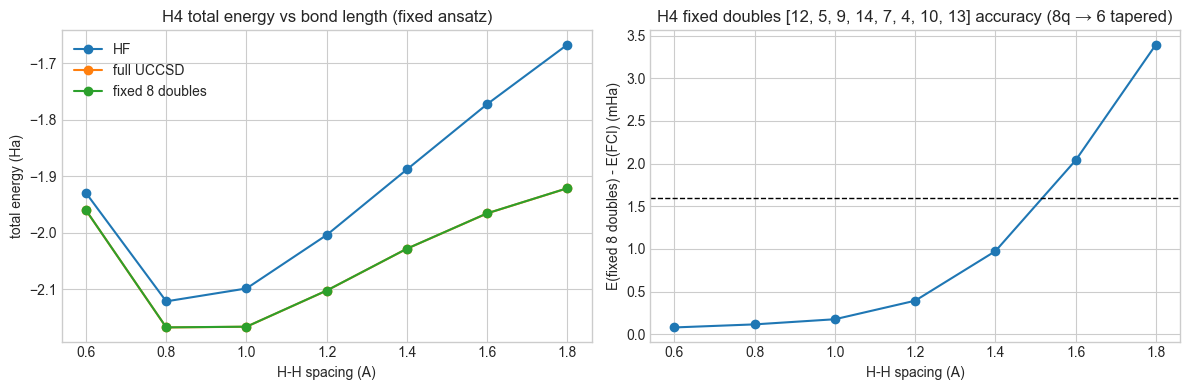

In [7]:
# Fixed ansatz: same 8 doubles at every bond length (param ids from top-8 at short d).
# Unlike the cell above, do NOT re-rank by |MP2 θ| at each geometry.
fixed_double_pids = [12, 5, 9, 14, 7, 4, 10, 13]
fixed_k = len(fixed_double_pids)

_, _, _, fixed_meta_df = build_reduced_topk_doubles_ucc(
    make_h4(report_d), active_space, fixed_k, fixed_pids=fixed_double_pids
)

fixed_scan_rows = []
for d in d_grid:
    mol = make_h4(d)

    # Reuse HF / full UCCSD / FCI from the earlier re-ranked scan.
    prev = scan_df.loc[np.isclose(scan_df["d_angstrom"], d)].iloc[0]
    e_hf = float(prev["E_HF_Ha"])
    e_as = float(prev["E_active_space_Ha"])
    e_fci_as = float(prev["E_topk_doubles_Ha"]) - float(prev["topk_minus_fci_active_mHa"]) / 1000.0

    reduced_ucc_d, selected_pids_d, selected_ex_ops_d, meta_d = build_reduced_topk_doubles_ucc(
        mol, active_space, fixed_k, fixed_pids=fixed_double_pids
    )
    e_fixed = reduced_ucc_d.kernel()

    fixed_scan_rows.append(
        {
            "d_angstrom": d,
            "E_HF_Ha": e_hf,
            "E_active_space_Ha": e_as,
            "E_fixed_doubles_Ha": e_fixed,
            "fixed_minus_active_mHa": (e_fixed - e_as) * 1000,
            "fixed_minus_fci_active_mHa": (e_fixed - e_fci_as) * 1000,
            "n_ex_ops_kept": len(selected_ex_ops_d),
            "selected_param_ids": str(selected_pids_d),
            "mp2_init_thetas": str([round(float(x), 6) for x in meta_d["mp2_init_theta"].tolist()]),
        }
    )

fixed_scan_df = pd.DataFrame(fixed_scan_rows).sort_values("d_angstrom").reset_index(drop=True)

print(
    f"Fixed ansatz uses the SAME doubles {fixed_double_pids} at every bond length "
    f"(MP2 amplitudes still taken from each geometry)."
)
print(f"Operator details below are for d = {report_d:.2f} A")
display(fixed_meta_df)
display(fixed_scan_df)

fig, axes = plt.subplots(1, 2, figsize=(12, 4))

fixed_scan_df.plot(
    x="d_angstrom",
    y=["E_HF_Ha", "E_active_space_Ha", "E_fixed_doubles_Ha"],
    marker="o",
    ax=axes[0],
)
axes[0].set_xlabel("H-H spacing (A)")
axes[0].set_ylabel("total energy (Ha)")
axes[0].set_title("H4 total energy vs bond length (fixed ansatz)")
axes[0].legend(["HF", "full UCCSD", f"fixed {fixed_k} doubles"])

fixed_scan_df.plot(
    x="d_angstrom",
    y="fixed_minus_fci_active_mHa",
    marker="o",
    legend=False,
    ax=axes[1],
)
axes[1].axhline(CHEM_ACC_MHA, color="black", linestyle="--", linewidth=1.0)
axes[1].set_xlabel("H-H spacing (A)")
axes[1].set_ylabel(f"E(fixed {fixed_k} doubles) - E(FCI) (mHa)")
axes[1].set_title(f"H4 fixed doubles {fixed_double_pids} accuracy (8q → 6 tapered)")

plt.tight_layout()
plt.show()


## Notes

- Molecule is linear `H4` in STO-3G via `h_chain(n_h=4, bond_distance=d)` (atoms at `0, d, 2d, 3d`). Do **not** use `tencirchem.molecule.h4(d)` — that name is a fixed Mole at 0.8 Å, not a factory.
- Full valence: `active_space=(4, 4)` → **8 qubits** (no frozen core).
- Z₂ qubit taper (α/β spin-block parity, same as `state_transfer/taper_lib.py`):
  **8 → 6 qubits**. This notebook selects doubles on the **8-qubit** register;
  tapering is exact for symmetry-respecting operators (see `state_transfer/tapered_doubles.ipynb`).
- Top-`k` selection (`top_k`) is **doubles only**, re-ranked by `|MP2 initial θ|`
  **at each bond length** (not a single fixed ansatz across the scan).
- The convergence cell sweeps every `k` so you can see how many doubles are enough
  for ≤ 1.6 mHa vs FCI. H₄ stretches into a strongly correlated regime at large `d`,
  so more doubles (or a multi-reference start) may be needed far from equilibrium.

